In [1]:
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid
import intake
import cf_xarray as cfxr
from access_nri_intake.experiment import use_datastore
from access_nri_intake.source import builders
import os
from xarray import SerializationWarning

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46077,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43103,Total threads: 1
Dashboard: /proxy/46803/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:44999,


<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [3]:
catalog = intake.cat.access_nri

In [4]:
expt_datastore = intake.open_esm_datastore(
    "./ssp585_th.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)

In [5]:
expt_datastore_1 = intake.open_esm_datastore(
    "./windthermal.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)


In [6]:
psi_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="ty_trans_rho",frequency = '1mon').to_dask()
psi_ctrl = psi_ctrl.ty_trans_rho

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [7]:
psi_th = expt_datastore.search(variable="ty_trans_rho",frequency = '1mon').to_dask()
psi_th = psi_th.ty_trans_rho

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [8]:
psi_wt = expt_datastore_1.search(variable="ty_trans_rho",frequency = '1mon').to_dask()
psi_wt = psi_wt.ty_trans_rho

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [9]:
rho_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="pot_rho_2",frequency = '1mon').to_dask()
rho_ctrl = rho_ctrl.pot_rho_2

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [10]:
rho_th =expt_datastore.search(variable="pot_rho_2",frequency = '1mon').to_dask()
rho_th = rho_th.pot_rho_2

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [11]:
rho_wt =expt_datastore_1.search(variable="pot_rho_2",frequency = '1mon').to_dask()
rho_wt = rho_wt.pot_rho_2

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [12]:
temp_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="temp",frequency = '1mon').to_dask()
temp_ctrl = temp_ctrl.temp

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [13]:
tendency_ctrl = xr.open_dataset('/g/data/x77/hm1221/PhD_P1_data/tendency_ctrl_mean_annual.nc')
pot_rho_1_ctrl = tendency_ctrl.pot_rho_1_ctrl

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/argopy/__init__.py:32: DeprecationWarning: The 'argopy.utilities' has moved to 'argopy.utils'. After 0.1.15, importing 'utilities' will raise an error. Please update your script.
  from . import utilities  # noqa: E402  # being deprecated until 0.1.15, then remove
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/core/npstats.py:238: DeprecationWarning: invalid escape sequence '\s'
  """Gaussian frequency spectrum (Bunney et al., 2014).
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.py:25: ResourceWarning: unclosed file <_io.TextIOWrapper name='/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.yml' mode='r' encoding='UTF-8'>
  VAR_ATTRIBUTES = yaml.load(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/w

In [14]:
def remap_depth(rho2,psi_avg):
    start_time = '2152-01-01'
    end_time = '2154-12-31'

    #rho2 = rho2.pint.quantify()
    
    #Mask the Mediteranean
    rho2 = rho2.cf.where(((rho2.cf['longitude'] < 0) | (rho2.cf['longitude'] > 45) ) |
                         ((rho2.cf['latitude'] < 10) | (rho2.cf['latitude'] > 48))
                        )

    rho2_time_mean = rho2.sel(time=slice(start_time, end_time)).mean('time')

    rho2_zonal_mean = rho2_time_mean.cf.mean("longitude").load()
    
    # nmin is the latitude index that corresponds to 78S
    nmin = int(list(rho2_zonal_mean.cf['latitude'].values).index(rho2_zonal_mean.cf.sel(latitude=-78, method='nearest').cf['latitude']))

    nmax = np.size(rho2_zonal_mean.cf['latitude'])
        
    psi_depth = 0 * psi_avg.copy(deep=True)
    #psi_depth = psi_depth.pint.dequantify()

    for ii in range(nmin, nmax):
        rho1 = rho2_zonal_mean.cf.isel(latitude=ii)
        rho1v = rho1.copy()
        z = rho1.cf['vertical']
        rho1 = rho1.rename({rho1.cf['vertical'].name: 'rho_ref'})
        rho1['rho_ref'] = np.array(rho1v)
        rho1.name = rho2_zonal_mean.cf['vertical'].name
        rho1.values = np.array(z)
        
        rho1 = rho1.isel(rho_ref = ~np.isnan(rho1.rho_ref)).drop_duplicates(dim='rho_ref', keep='first')

        rho1 = rho1.interp(rho_ref = psi_avg.cf['vertical'].values,
                           kwargs={"bounds_error": False, "fill_value": (0, 6000)})
        psi_depth[:, ii] = rho1.rename({'rho_ref': psi_avg.cf['vertical'].name})

    psi_avg2 = psi_avg.rename({"grid_yu_ocean" : "yu_ocean"}) # purely for automatic renaming later

    new_psi_avg = xr.DataArray(data = psi_avg2.values,
                               dims = ["pot_rho_2", "yu_ocean"],
                               coords = dict(latitude_b=(["yu_ocean"], psi_avg2["yu_ocean"].values),
                                             depth=(["pot_rho_2", "yu_ocean"], psi_depth.values)),
                               attrs = psi_avg.attrs)

    #new_psi_avg.attrs['units'] = psi_avg.pint.units
    
    #new_psi_avg = new_psi_avg.pint.quantify()

    new_psi_avg = new_psi_avg.rename({"yu_ocean": "yu_ocean"})

    #psi_depth = psi_depth.pint.quantify()
    
    return psi_depth, new_psi_avg

In [15]:
# calculate the streamfunction
def load_streamfunction(psi):
    start_time = '2152-01-01'
    end_time = '2154-12-31'

    psi = psi.sel(time=slice(start_time, end_time))
    psi = psi.cf.sum("longitude")

    
    ρ0 = 1025 # mean density of sea-water [kg/m³]
    
    # convert to Sv
    psi = psi / (1e6 * ρ0)
    
    return psi

In [16]:
# accumulate the psi
def sum_in_vertical(psi):
    psi_avg = psi.cf.cumsum("vertical").mean("time") - psi.cf.sum("vertical").mean("time")


    psi_avg.load()

    return psi_avg

In [17]:
psi_ctrl = load_streamfunction(psi_ctrl)
psi_avg_ctrl = sum_in_vertical(psi_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 81.58 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [18]:
psi_th = load_streamfunction(psi_th)
psi_avg_th = sum_in_vertical(psi_th)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 136.52 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [19]:
psi_wt = load_streamfunction(psi_wt)
psi_avg_wt = sum_in_vertical(psi_wt)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 11.68 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [20]:
psi_depth_ctrl, pci_acg_ctrl_new = remap_depth(rho_ctrl,psi_avg_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 81.71 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [21]:
psi_depth_th, pci_acg_th_new = remap_depth(rho_th,psi_avg_th)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 314.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [22]:
psi_depth_wt, pci_acg_wt_new = remap_depth(rho_wt,psi_avg_wt)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 20.68 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [23]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')
new_coord = new_coord.sel(yt_ocean = slice(-90,-40))

In [24]:
def var_2d_time_mean(var):
    var_mean = var.mean('time').mean('xt_ocean_sub01').load()
    return var_mean

In [25]:
pot_rho_1_ctrl = var_2d_time_mean(pot_rho_1_ctrl)

In [26]:
start_time='2152-02-01'
end_time='2152-02-28'

In [27]:
st_ocean = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/st_ocean.nc')

In [28]:
def depth_max_gradient(temp):
    T_1000 = temp.sel(st_ocean = slice(0,1000)).sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time,end_time))
    time_values = T_1000['time'].values
    T_1000_value = T_1000.values
    st_ocean_1000 = st_ocean[0:46].values
    depth_layer = (st_ocean_1000[0:-2]+st_ocean_1000[1:-1])/2
    depth_max_grad = np.zeros((len(time_values),666,3600))
    # low boundary calculation
    for i in range(len(time_values)):
                   for j in range(666):
                       for k in range(3600):
                           T_gradient = (T_1000_value[i,0:-2,j,k]-T_1000_value[i,1:-1,j,k])/(st_ocean_1000[0:-2]-st_ocean_1000[1:-1])
                           depth_max_grad[i,j,k] = depth_layer[np.argmax(T_gradient)]
    bound_low = xr.DataArray(depth_max_grad, dims = ['time','yt_ocean', 'xt_ocean'], coords = [time_values,T_1000.yt_ocean.values,T_1000.xt_ocean.values])
    bound_low_mean = bound_low.mean('xt_ocean').load()
    bound_low.load()
    return [bound_low,bound_low_mean]

In [29]:
bound_low_ctrl,bound_low_ctrl_mean = depth_max_gradient(temp_ctrl)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 181.97 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [30]:
bound_low_ctrl_mean = bound_low_ctrl_mean.squeeze(dim='time')

In [31]:
bound_low_ctrl_mean

<xarray.DataArray (yt_ocean: 666)> Size: 5kB
array([  1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   1.11100769,
         1.11100769,   1.11100769,   1.11100769,   3.03320083,
         5.84671204,   8.79057589,  11.81653333,  15.6271762 ,
        20.13870701,  22.31742125,  24.18392622,  26.44611215,
        29.4810171 ,  28.97155337,  31.55975871,  32.86106456,
        34.56159103,  37.84943681,  38.33898367,  39.62544675,
        41.00705411,  47.65274424,  51.21163265,  54.01521397,
...
       210.055042  , 207.70906627, 206.05017483, 204.20357459,
       203.19273551, 202.69639215, 200.96616075, 199.05685249,
       199.0702266 , 196.63592749, 194.07424436, 197.07010543,
       198.10864971, 200.01969735, 201.25822994, 204.25090284,
       209.79855412, 211.90003181, 215.04712704, 218.58052056,
       221.83677504, 221.88862507, 223.42589928, 221.49796857,
       223.98815553, 223.26465291, 220.1864133 , 216.90943067,
       212.41534329, 213.24765229, 209.23290086, 208.80046976,
       205.33678054, 207.09154671, 204.49148811, 201.21078778,
       197.89226922, 196.62447086, 198.17932498, 196.31708796,
       193.52319339, 193.23285145, 196.66088422, 198.74451294,
       201.07154774, 202.07214154, 201.00386162, 202.19572704,
       204.58665025, 208.81169251, 210.22801116, 212.66259563,
       217.17450141, 216.33030639, 216.74115205, 217.43305622,
       214.99926004, 213.91172329, 213.93705285, 213.39366843,
       214.81785722, 217.88432282, 216.98441547, 217.1421395 ,
       218.05631946, 217.27416675, 220.78306334, 225.68262338,
       228.49930922, 232.25285792, 230.79185606, 229.93953735,
       229.23001904, 224.88084422, 223.15196056, 225.48315935,
       227.46262735, 227.73751229])
Coordinates:
    time      object 8B 2152-02-15 00:00:00
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -50.09 -50.03

In [32]:
anoth = pci_acg_th_new - pci_acg_ctrl_new

In [33]:
anoth = anoth.assign_coords(yu_ocean=pci_acg_th_new.yu_ocean)

# Adding coordinate with shape (80, 2700)
anoth = anoth.assign_coords(depth=(pci_acg_th_new.depth))

In [34]:
anowt = pci_acg_wt_new - pci_acg_ctrl_new
anowt = anowt.assign_coords(yu_ocean=pci_acg_wt_new.yu_ocean)

# Adding coordinate with shape (80, 2700)
anowt = anowt.assign_coords(depth=(pci_acg_wt_new.depth))

In [35]:
pci_acg_th_new

<xarray.DataArray (pot_rho_2: 80, yu_ocean: 2700)> Size: 864kB
array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -5.2324086e-03, -6.2185880e-03, -4.6111299e-03],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -4.9519269e-03, -6.0020117e-03, -4.4328547e-03],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -4.7621401e-03, -5.6304634e-03, -4.3451125e-03],
       ...,
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -6.9849193e-10, -6.9849193e-10,  2.9103830e-10],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -6.9849193e-10, -6.9849193e-10,  2.9103830e-10],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -6.9849193e-10, -6.9849193e-10,  2.9103830e-10]], dtype=float32)
Coordinates:
    latitude_b  (yu_ocean) float64 22kB -81.09 -81.05 -81.0 ... 89.92 89.96 90.0
    depth       (pot_rho_2, yu_ocean) float32 864kB 0.0 0.0 0.0 ... 6e+03 6e+03
Dimensions without coordinates: pot_rho_2, yu_ocean

<>:26: DeprecationWarning: invalid escape sequence '\c'
<>:56: DeprecationWarning: invalid escape sequence '\c'
<>:86: DeprecationWarning: invalid escape sequence '\c'
<>:26: DeprecationWarning: invalid escape sequence '\c'
<>:56: DeprecationWarning: invalid escape sequence '\c'
<>:86: DeprecationWarning: invalid escape sequence '\c'
<unknown>:26: DeprecationWarning: invalid escape sequence '\c'
<unknown>:56: DeprecationWarning: invalid escape sequence '\c'
<unknown>:86: DeprecationWarning: invalid escape sequence '\c'
/jobfs/157147767.gadi-pbs/ipykernel_3653525/728360615.py:26: DeprecationWarning: invalid escape sequence '\c'
  plt.xlabel('Latitude ($^\circ$N)', fontsize = 12)
/jobfs/157147767.gadi-pbs/ipykernel_3653525/728360615.py:56: DeprecationWarning: invalid escape sequence '\c'
  plt.xlabel('Latitude ($^\circ$N)', fontsize = 12)
/jobfs/157147767.gadi-pbs/ipykernel_3653525/728360615.py:86: DeprecationWarning: invalid escape sequence '\c'
  plt.xlabel('Latitude ($^\circ$N)', font

([<matplotlib.axis.YTick at 0x1503bdd60b50>,
 [Text(0, -24, '-24'),
  Text(0, -20, '-20'),
  Text(0, -16, '-16'),
  Text(0, -12, '-12'),
  Text(0, -8, '-8'),
  Text(0, -4, '-4'),
  Text(0, 0, '0'),
  Text(0, 4, '4'),
  Text(0, 8, '8'),
  Text(0, 12, '12'),
  Text(0, 16, '16'),
  Text(0, 20, '20'),
  Text(0, 24, '24')])

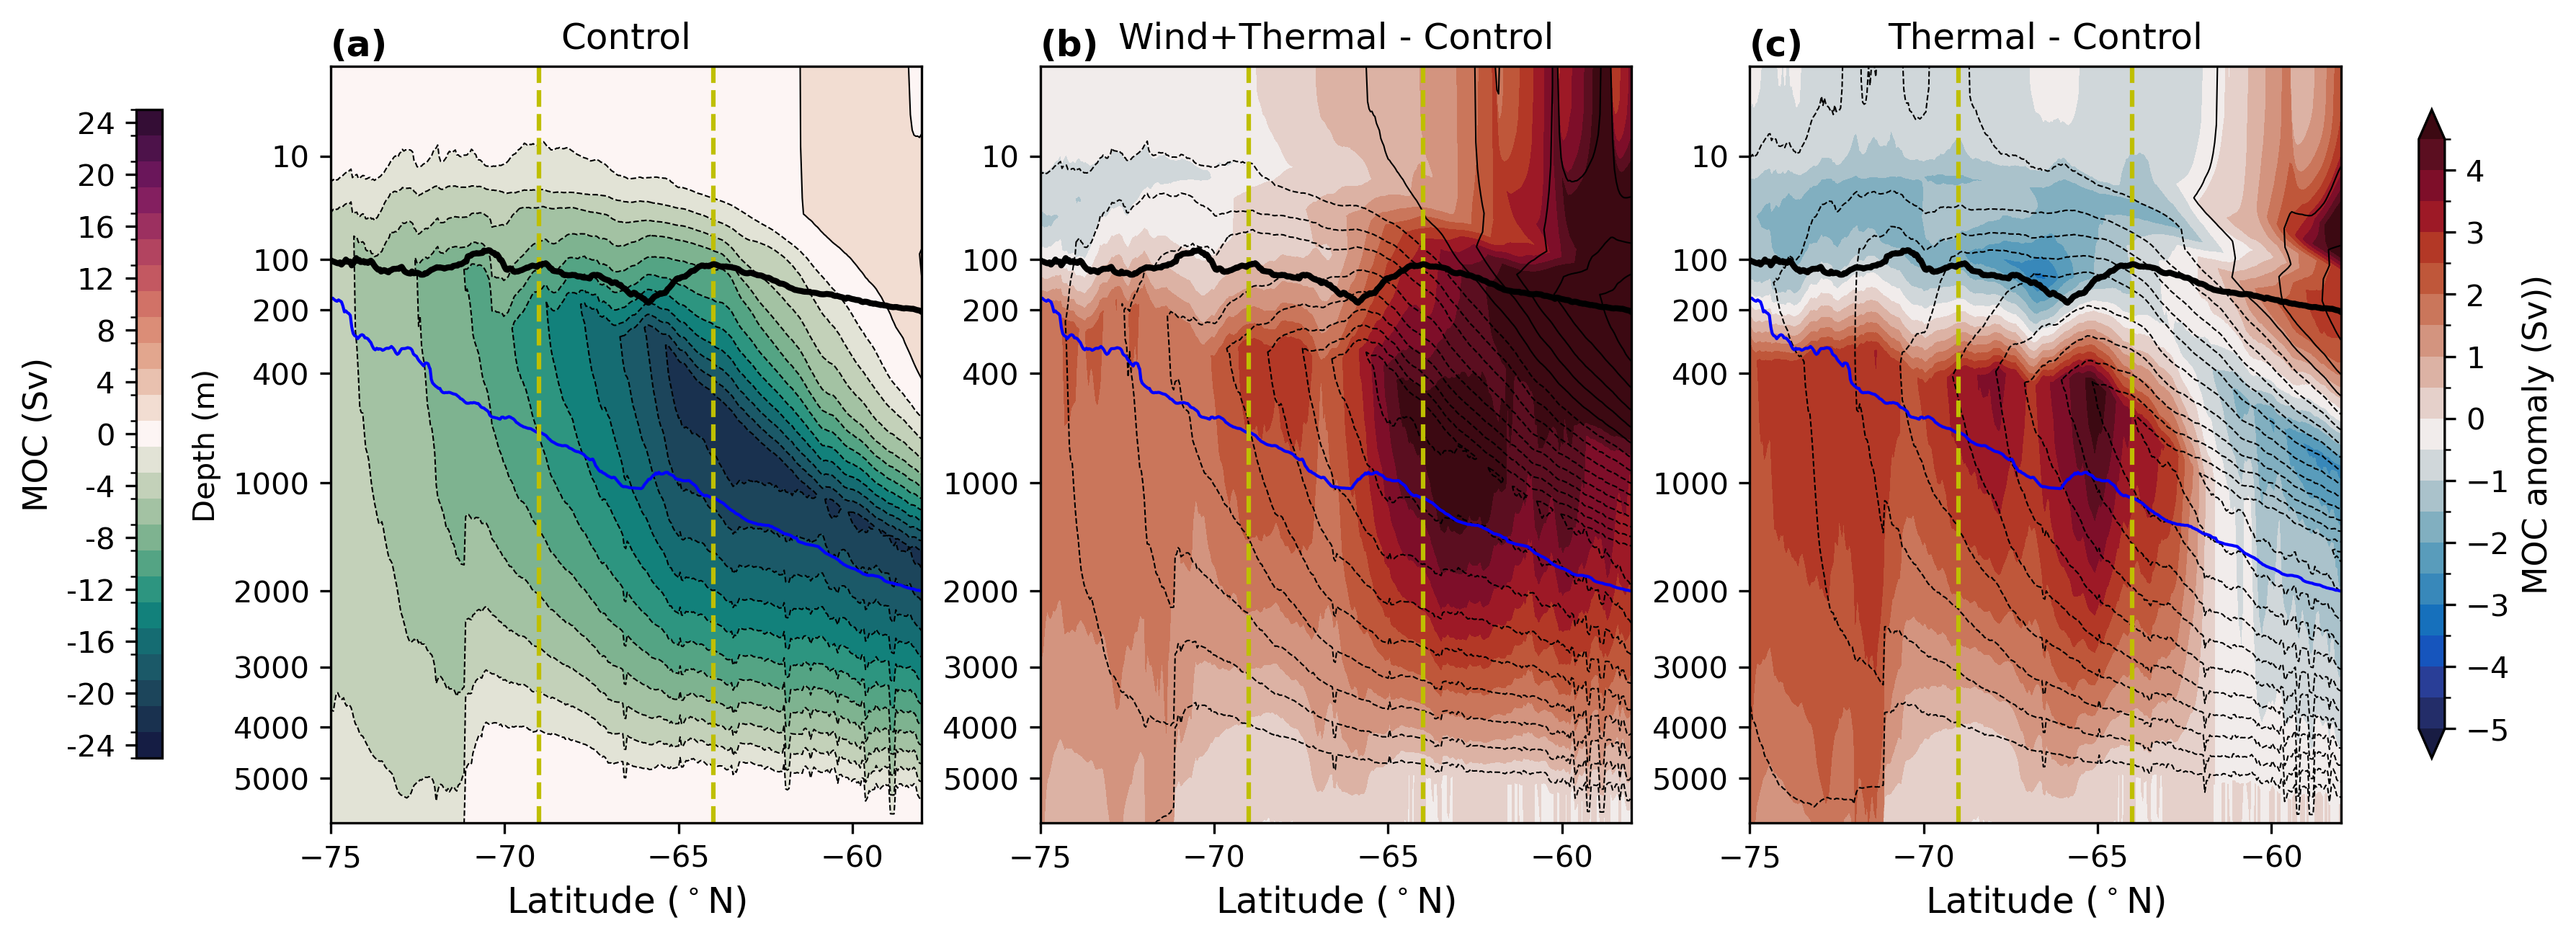

In [41]:
# For new figure 8
fig = plt.figure(figsize=(12,10),dpi = 300)
variable_name = ['Control','Thermal - Control','Wind+Thermal - Control']
max_psi = 25 # Sv
    
    # how we compute the levels may seem complicated, we just want to avoid a 0 contour
    # so that the plot looks soothing to the eye
levels =  np.hstack((np.arange(-max_psi, 0, 2), np.flip(-np.arange(-max_psi, 0, 2))))
ax = plt.subplot(2,3,1)

p4 = pci_acg_ctrl_new[1:,:].plot.contourf(y="depth", x='latitude_b',
                          levels = levels,
                          cmap=cm.cm.curl,
                          add_colorbar = False
                          )
pci_acg_ctrl_new[1:,:].plot.contour(y="depth", x='latitude_b',
                          levels=levels,colors='k', linewidths=0.5
                          )
pot_rho_1_ctrl.plot.contour(
                          levels=[1032.5],colors='b', linewidths=1.
                          )
plt.gca().invert_yaxis()
ax.set_title(f'{variable_name[0]}', fontsize = 12)
plt.xlim([-75, -58])
plt.ylabel('Depth (m)')
plt.xlabel('Latitude ($^\circ$N)', fontsize = 12)
plt.plot([-69,-69], [0,6000], linestyle='--', color='y')    
plt.plot([-64,-64], [0,6000], linestyle='--', color='y') 
plt.plot(bound_low_ctrl_mean.yt_ocean.values, bound_low_ctrl_mean.values, c = 'k',linewidth=2)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
ax.text(
        0., 1.05, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax = plt.subplot(2,3,3)
p2 = (anoth[1:,:]).plot.contourf(y="depth", x='latitude_b',levels=np.arange(-5,5,0.5),
                    cmap=cm.cm.balance, add_colorbar = False)
pci_acg_th_new[1:,:].plot.contour(y="depth", x='latitude_b',levels=levels, colors='k', linewidths=0.5)
#new_psi_avg_th[1:,:].plot.contour(y="depth",levels=[0.1], colors='deeppink', linewidths=1.5,linestyles='-')
#new_psi_avg_ctrl[1:,:].plot.contour(y="depth",levels=[0.1], colors='deeppink', linewidths=1.5)
pot_rho_1_ctrl.plot.contour(
                          levels=[1032.5],colors='b', linewidths=1.
                          )
plt.gca().invert_yaxis()
ax.set_title(f'{variable_name[1]}', fontsize = 12)
plt.xlim([-75, -58])
plt.ylabel('')
plt.xlabel('Latitude ($^\circ$N)', fontsize = 12)
plt.plot([-69,-69], [0,6000], linestyle='--', color='y')    
plt.plot([-64,-64], [0,6000], linestyle='--', color='y') 
plt.plot(bound_low_ctrl_mean.yt_ocean.values, bound_low_ctrl_mean.values, c = 'k',linewidth=2)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
ax.text(
        0., 1.05, '(c)', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax = plt.subplot(2,3,2)
p2 = (anowt[1:,:]).plot.contourf(y="depth", x='latitude_b',levels=np.arange(-5,5,0.5),
                    cmap=cm.cm.balance, add_colorbar = False)
pci_acg_wt_new[1:,:].plot.contour(y="depth", x='latitude_b',levels=levels, colors='k', linewidths=0.5)
#new_psi_avg_th[1:,:].plot.contour(y="depth",levels=[0.1], colors='deeppink', linewidths=1.5,linestyles='-')
#new_psi_avg_ctrl[1:,:].plot.contour(y="depth",levels=[0.1], colors='deeppink', linewidths=1.5)
pot_rho_1_ctrl.plot.contour(
                          levels=[1032.5],colors='b', linewidths=1.
                          )
plt.gca().invert_yaxis()
ax.set_title(f'{variable_name[2]}', fontsize = 12)
plt.xlim([-75, -58])
plt.ylabel('')
plt.xlabel('Latitude ($^\circ$N)', fontsize = 12)
plt.plot([-69,-69], [0,6000], linestyle='--', color='y')    
plt.plot([-64,-64], [0,6000], linestyle='--', color='y') 
plt.plot(bound_low_ctrl_mean.yt_ocean.values, bound_low_ctrl_mean.values, c = 'k',linewidth=2)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
ax.text(
        0., 1.05, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

tick = np.arange(-24,25,4)
# colorbar 
ax_cb2 = plt.axes([0.93, 0.56, 0.01, 0.3])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='max')
cb.ax.set_ylabel('MOC anomaly (Sv))', fontsize = 11)

ax_cb2 = plt.axes([0.05, 0.56, 0.01, 0.3])
cb = plt.colorbar(p4, cax=ax_cb2,  orientation='vertical',extend='max')
cb.ax.set_ylabel('MOC (Sv)', fontsize = 11)
plt.yticks(tick, tick)
cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')
#tick = np.arange(-24,25,4)
#ax_cb2 = plt.axes([0.53, 0.56, 0.01, 0.3])
#cb = plt.colorbar(p4, cax=ax_cb2,  orientation='vertical',extend='max')
#cb.ax.set_ylabel('MOC (Sv)', fontsize = 11)
plt.yticks(tick, tick)
#cb.ax.yaxis.set_ticks_position('left')
#cb.ax.yaxis.set_label_position('left')